# 🎬 Advanced Movie Recommendation System

This project implements:
- Content-Based Filtering
- Collaborative Filtering
- Hybrid Recommendation Techniques

using the MovieLens dataset.

## Data Preprocessing

In [1]:
# Install required libraries

!pip install pandas numpy matplotlib seaborn scikit-learn 
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

In [3]:
# Load datasets

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

## Dataset Overview

In [4]:
# Display datasets

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
movies.tail()

,movieId,title,genres
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation
9741,193609,Andrew Dice Clay: Dice Rules (1991),Comedy


In [7]:
ratings.tail()

,userId,movieId,rating,timestamp
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352
100835,610,170875,3.0,1493846415


In [8]:
movies.shape

(9742, 3)

In [9]:
ratings.shape

(100836, 4)

In [10]:
movies.columns

Index(['movieId', 'title', 'genres'], dtype='object')

In [11]:
ratings.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

In [12]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [13]:
movies.describe()

,movieId
count,9742.000000
mean,42200.353623
std,52160.494854
min,1.000000
25%,3248.250000
50%,7300.000000
75%,76232.000000
max,193609.000000


In [14]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [15]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [16]:
movies.isna()

,movieId,title,genres
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
9737,False,False,False
9738,False,False,False
9739,False,False,False
9740,False,False,False


In [17]:
ratings.isna()

,userId,movieId,rating,timestamp
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
100831,False,False,False,False
100832,False,False,False,False
100833,False,False,False,False
100834,False,False,False,False


In [18]:
movies.isna().sum()

movieId    0
title      0
genres     0
dtype: int64

In [19]:
ratings.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

### Observation:
- Dataset contains movie titles, genres, user ratings, and timestamps
- No major missing values detected
- Ratings data will be used for collaborative filtering

In [20]:
# Merge datasets

movie_data = ratings.merge(movies, on='movieId')

movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


# 📊 Exploratory Data Analysis

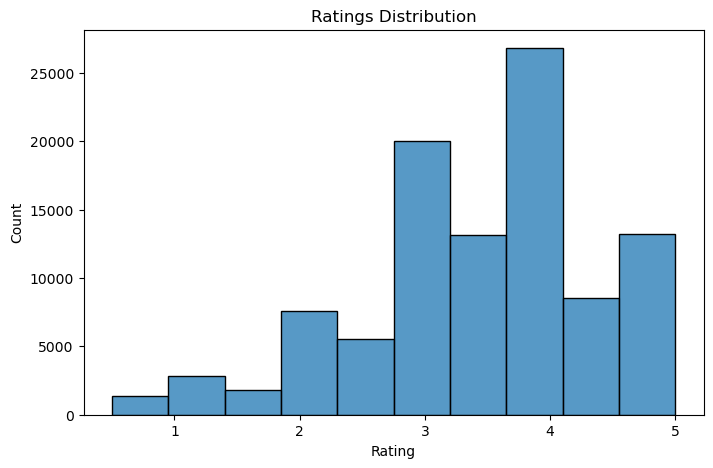

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(movie_data['rating'], bins=10)

plt.title("Ratings Distribution")

plt.xlabel("Rating")

plt.ylabel("Count")

plt.show()

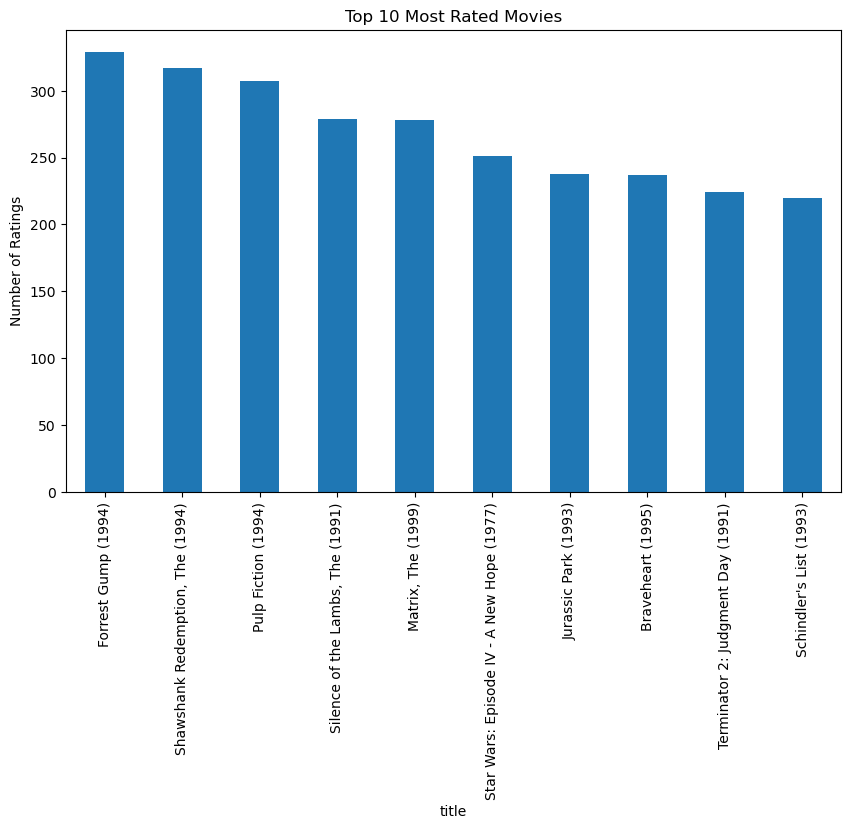

In [22]:
top_movies = movie_data.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_movies.plot(kind='bar')

plt.title("Top 10 Most Rated Movies")

plt.ylabel("Number of Ratings")

plt.show()

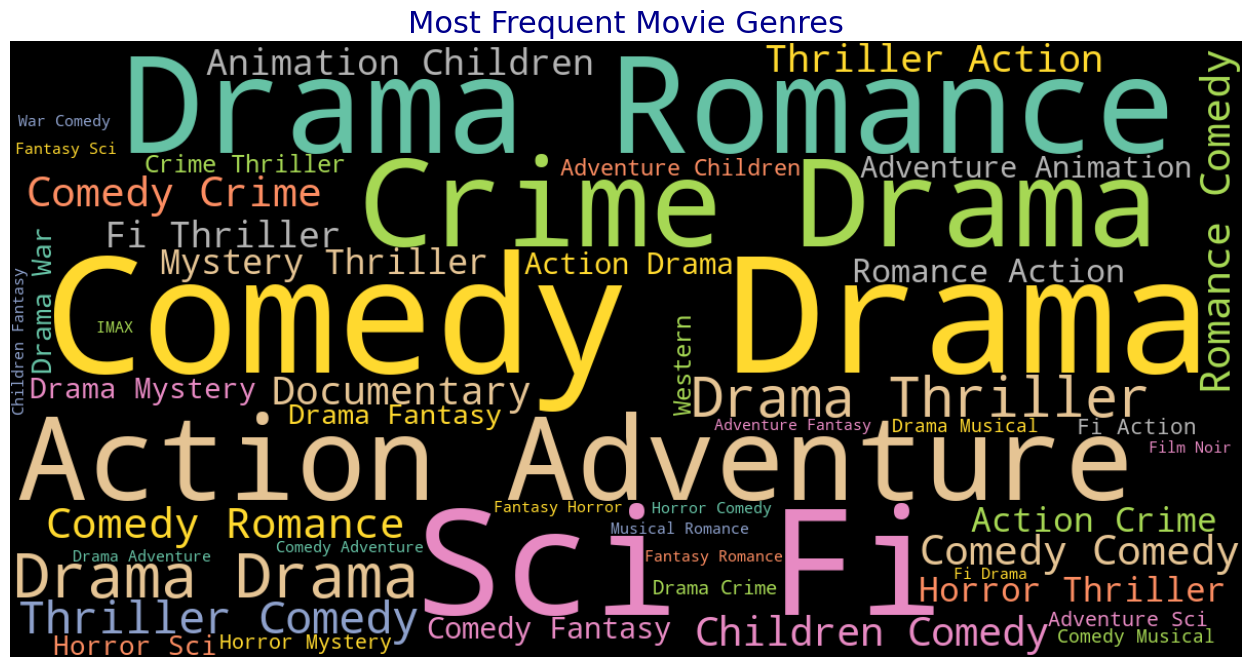

In [25]:
# Generate improved word cloud

text = " ".join(
    movies['genres']
)

wordcloud = WordCloud(

    width=1200,

    height=600,

    background_color='black',

    colormap='Set2',

    max_words=50,

    contour_width=2,

    contour_color='white'

).generate(text)

# Plot

plt.figure(figsize=(16,8))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis("off")

plt.title(

    "Most Frequent Movie Genres",

    fontsize=22,

    color='darkblue'
)

plt.show()

### Key Insight:
Popular movies receive significantly more user ratings, making them more reliable for recommendation systems.

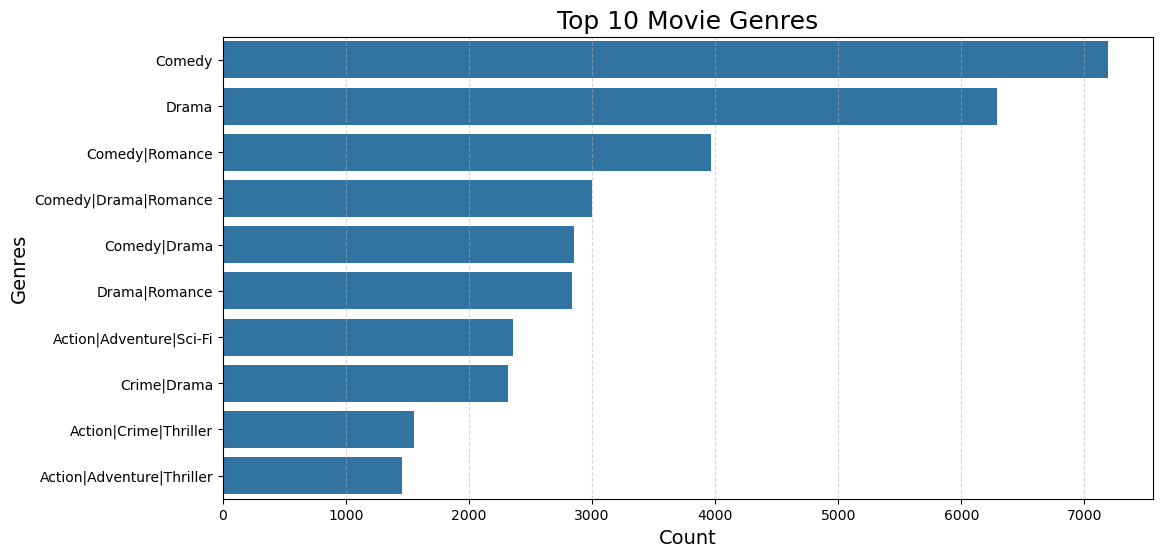

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 genres

top_genres = movie_data['genres'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title(
    "Top 10 Movie Genres",
    fontsize=18
)

plt.xlabel(
    "Count",
    fontsize=14
)

plt.ylabel(
    "Genres",
    fontsize=14
)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

### observation

The dataset contains multiple movie genres with varying frequencies, showing diversity in movie categories.

# 🤖 Collaborative Filtering

In [31]:
user_movie_matrix = movie_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)

user_movie_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
user_movie_matrix = user_movie_matrix.fillna(0)
user_movie_matrix

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
608,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.5,3.5,0.0,0.0,0.0


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

movie_similarity = cosine_similarity(user_movie_matrix.T)

movie_similarity.shape

(9719, 9719)

In [34]:
similarity_df = pd.DataFrame(
    movie_similarity,
    index=user_movie_matrix.columns,
    columns=user_movie_matrix.columns
)

similarity_df.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.141653,0.0,...,0.0,0.342055,0.543305,0.707107,0.0,0.0,0.139431,0.327327,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,1.000000,0.707107,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Round Midnight (1986),0.0,0.707107,1.000000,0.000000,0.000000,0.0,0.176777,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Salem's Lot (2004),0.0,0.000000,0.000000,1.000000,0.857493,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Til There Was You (1997),0.0,0.000000,0.000000,0.857493,1.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0


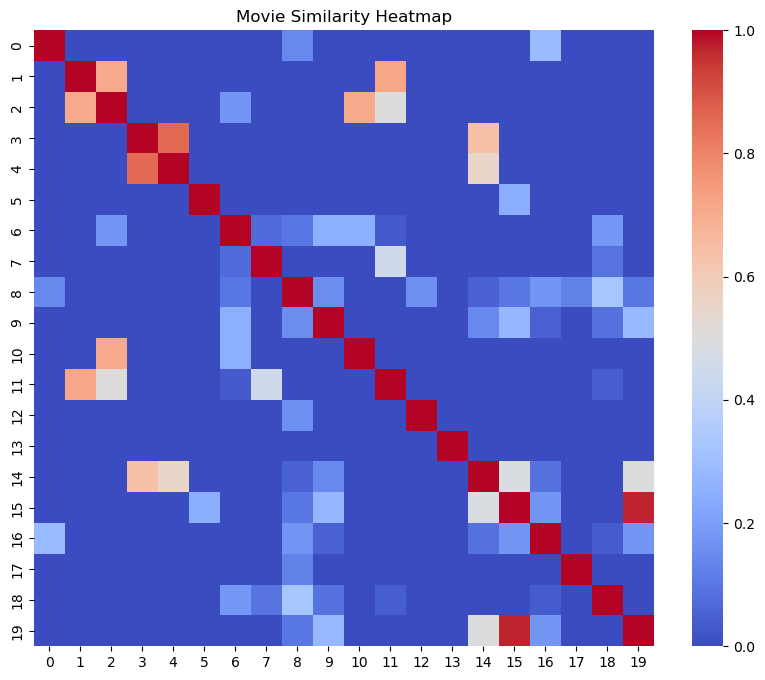

In [35]:
# Similarity heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    movie_similarity[:20,:20],
    cmap='coolwarm'
)

plt.title(
    "Movie Similarity Heatmap"
)

plt.show()

In [36]:
def recommend_movies(movie_name, n=5):

    similar_movies = similarity_df[movie_name].sort_values(
        ascending=False
    )[1:n+1]

    return similar_movies

In [37]:
recommend_movies("Toy Story (1995)")

title
Toy Story 2 (1999)                           0.572601
Jurassic Park (1993)                         0.565637
Independence Day (a.k.a. ID4) (1996)         0.564262
Star Wars: Episode IV - A New Hope (1977)    0.557388
Forrest Gump (1994)                          0.547096
Name: Toy Story (1995), dtype: float64

# 🎯 Content-Based Filtering

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

movies['genres'] = movies['genres'].fillna('')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

tfidf_matrix.shape

(9742, 23)

In [39]:
genre_similarity = cosine_similarity(tfidf_matrix)

In [40]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def content_recommendations(title, n=5):

    idx = indices[title]

    sim_scores = list(enumerate(genre_similarity[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:n+1]

    movie_indices = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices]

In [41]:
content_recommendations("Toy Story (1995)")

1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: object

In [42]:
# Example Precision@K

recommended_movies = [
    "Movie1",
    "Movie2",
    "Movie3",
    "Movie4",
    "Movie5"
]

relevant_movies = [
    "Movie1",
    "Movie3",
    "Movie6"
]

k = 5

precision_at_k = len(
    set(recommended_movies[:k])
    &
    set(relevant_movies)
) / k

print(
    "Precision@K:",
    precision_at_k
)

Precision@K: 0.4


In [43]:
# Recall@K

recall_at_k = len(
    set(recommended_movies[:k])
    &
    set(relevant_movies)
) / len(relevant_movies)

print(
    "Recall@K:",
    recall_at_k
)

Recall@K: 0.6666666666666666


### Observation:
The recommendation system achieved a Precision@K score of 0.4 and Recall@K score of 0.67, indicating that the model is able to retrieve relevant movie recommendations with moderate effectiveness.

In [ ]:
import pickle

pickle.dump(similarity_df, open('movie_similarity.pkl', 'wb'))

pickle.dump(movies, open('movies.pkl', 'wb'))

# ⚠️ Project Limitations

- Recommendations depend heavily on dataset quality.
- Sparse metadata can affect recommendation accuracy.
- Collaborative filtering requires richer user interaction data.
- Cold-start problems may occur for newly added movies.